In [1]:
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Model evaluation
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

In [2]:
data_folder = 'datasets_combined_ravdess_crema_tess'

# Paths to your previously saved files
X_train = np.load(f'../{data_folder}/X_deep_train.npy')
y_train = np.load(f'../{data_folder}/y_deep_train.npy')
X_val = np.load(f'../{data_folder}/X_deep_val.npy')
y_val = np.load(f'../{data_folder}/y_deep_val.npy')
X_test = np.load(f'../{data_folder}/X_deep_test.npy')
y_test = np.load(f'../{data_folder}/y_deep_test.npy')

# Optional: Subset only the MFCCs / Exclude the delta coefficients
X_train = X_train[:,:,:30]
X_val = X_val[:,:,:30]
X_test = X_test[:,:,:30]

# Feature Engineering: Adding noise for data diversity
# noise_factor = 0.005
# X_train = X_train + noise_factor * np.random.randn(*X_train.shape)

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)
# Example shape: (num_samples, time_steps, num_features)

Shapes: (6390, 435, 30) (2130, 455, 30) (2130, 489, 30)


In [3]:
# --- Normalize features ---
# compute mean and sd from the train data
mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

# standardize
X_train = (X_train - mean) / (std)
X_val = (X_val - mean) / (std)
X_test = (X_test - mean) / (std)

In [4]:
# Suppose y_train, y_val, y_test are like [1, 2, 3, 4, 5, 6, 7, 8]
# Convert them to zero-based labels (required for to_categorical)
y_train_enc = y_train - 1
y_val_enc = y_val - 1
y_test_enc = y_test - 1

# Get number of classes automatically
num_classes = np.max(y_train_enc) + 1

# Convert to one-hot (instead of labels being a single integer, converts it to a binary vector)
# e.g. if happy = 2, it will be represented like this -> [0,1,0,0,0,0,0,0]
y_train_cat = to_categorical(y_train_enc, num_classes)
y_val_cat = to_categorical(y_val_enc, num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes)

# --- Get shape info for the model ---
time_steps = X_train.shape[1]
num_features = X_train.shape[2]

print(f"Time steps: {time_steps}, Num features: {num_features}, Classes: {num_classes}")

Time steps: 435, Num features: 30, Classes: 7


In [5]:
model = Sequential([
    # 1️⃣ First Bidirectional LSTM layer
    Bidirectional(LSTM(
        units=128,
        return_sequences=True,           # important for stacking
        input_shape=(time_steps, num_features)
    )),

    # Optional normalization & regularization
    BatchNormalization(),
    Dropout(0.3),

    # 2️⃣ Second Bidirectional LSTM layer
    Bidirectional(LSTM(
        units=64,
        return_sequences=False           # last layer, only final output
    )),

    BatchNormalization(),
    Dropout(0.3),
    
    # 3️⃣ Dense layers for classification
    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',                     # good default optimizer
    loss='categorical_crossentropy',      # for multi-class classification
    metrics=['accuracy']
)

model.summary()

c:\AowenC\School\Y4 S1\MH4510\Project\Statistical-Learning-and-Data-Mining\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Add Callbacks for Efficient Training

callbacks = [
    EarlyStopping(
        patience=10,               # stop if val_loss doesn't improve for 10 epochs
        restore_best_weights=True # revert to best model
    ),
    ModelCheckpoint(
        'best_lstm_model.keras',   # file to save the best model
        save_best_only=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6
    )
]

In [9]:
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=50,             # upper limit — early stopping will likely end before this
    batch_size=32,         # number of samples per gradient update
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 242s 1s/step - accuracy: 0.2609 - loss: 1.9311 - val_accuracy: 0.4099 - val_loss: 1.5630 - learning_rate: 0.0010
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.3900 - loss: 1.4999 - val_accuracy: 0.4798 - val_loss: 1.2757 - learning_rate: 0.0010
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 183s 916ms/step - accuracy: 0.4693 - loss: 1.3235 - val_accuracy: 0.4939 - val_loss: 1.2280 - learning_rate: 0.0010
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 167s 837ms/step - accuracy: 0.4822 - loss: 1.2686 - val_accuracy: 0.5192 - val_loss: 1.1811 - learning_rate: 0.0010
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.4950 - loss: 1.2314 - val_accuracy: 0.5188 - val_loss: 1.1789 - learning_rate: 0.0010
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - accuracy: 0.5058 - loss: 1.2102 - val_accuracy: 0.5066 - val_loss: 1.1586 - learning_rate: 0.0010
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2084s 10s/step - accuracy: 0.5203 - 

## Model Evaluation

In [80]:
# Evaluate on the test set
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"✅ Test Accuracy: {test_acc:.2%}")

✅ Test Accuracy: 27.31%


In [45]:
# Classification Report
y_pred = model.predict(X_test)
y_pred_labels = y_pred.argmax(axis=1) + 1  # +1 if your labels start at 1

unique_classes = [str(c) for c in sorted(np.unique(y_test))]

print(classification_report(y_test, y_pred_labels, target_names=unique_classes))

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 649ms/step
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        14
           2       0.34      0.82      0.48        28
           3       0.26      0.28      0.27        29
           4       0.00      0.00      0.00        29
           5       0.64      0.24      0.35        29
           6       0.09      0.03      0.05        29
           7       0.33      0.03      0.06        29
           8       0.22      0.59      0.31        29

    accuracy                           0.26       216
   macro avg       0.23      0.25      0.19       216
weighted avg       0.25      0.26      0.20       216



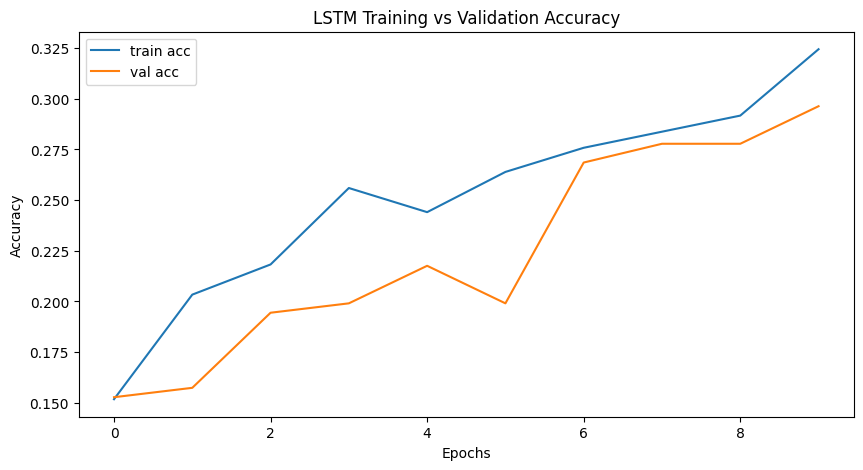

In [73]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('LSTM Training vs Validation Accuracy')
plt.show()

In [62]:
np.unique(y_train, return_counts=True)


(array([1, 2, 3, 4, 5, 6, 7, 8]),
 array([ 68, 135, 135, 134, 134, 134, 134, 134]))